In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("train_data_ibm.csv")
test_df = pd.read_csv("test_data_ibm.csv")

# Extract features and targets
X_train = train_df.drop(columns=['Attrition']).values
y_train = train_df['Attrition'].values

X_test = test_df.drop(columns=['Attrition']).values
y_test = test_df['Attrition'].values

In [3]:
#Q-Table Dictionary Initialization
q_table = {}

def get_q_values(state_key):
    if state_key not in q_table:
        q_table[state_key] = np.zeros(2)
    return q_table[state_key]

def get_state_representation(row_vector):
    return tuple(np.round(row_vector, 0))

In [4]:
alpha = 0.1          # TD learning rate parameter
gamma = 0.95         # Discount factor lookahead weight
epsilon = 0.5        # High initial exploration probability
epsilon_decay = 0.999 # Smooth exponential decay factor
min_epsilon = 0.05   # Baseline exploration floor
episodes = 5000      # Total reinforcement training loops
steps_per_episode = 10

reward_history = []
epsilon_history = []

print(f"Training Off-Policy Q-Learning agent over {episodes} corporate episodes...")

Training Off-Policy Q-Learning agent over 5000 corporate episodes...


In [5]:
#Training Engine (Bellman TD Bootstrapping)
for episode in range(episodes):
    idx = random.randint(0, len(X_train) - 2)
    S = get_state_representation(X_train[idx])

    total_episode_reward = 0

    for step in range(steps_per_episode):
        q_values_S = get_q_values(S)

        if random.uniform(0, 1) < epsilon:
            A = random.randint(0, 1)
        else:
            A = np.argmax(q_values_S)
        actual_attrition = y_train[idx]
        if A == actual_attrition:
            R = 1.0
        else:
            R = -3.0 if actual_attrition == 1 else -1.0

        total_episode_reward += R

        idx += 1
        if idx >= len(X_train):
            idx = 0

        S_prime = get_state_representation(X_train[idx])
        q_values_S_prime = get_q_values(S_prime)

        max_q_S_prime = np.max(q_values_S_prime)
        q_table[S][A] = q_table[S][A] + alpha * (R + gamma * max_q_S_prime - q_table[S][A])
        S = S_prime
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    reward_history.append(total_episode_reward)
    epsilon_history.append(epsilon)

print("Q-Table policy optimization completed successfully for IBM HR Attrition data!")

Q-Table policy optimization completed successfully for IBM HR Attrition data!


In [6]:
test_predictions = []

print("Running test matrix validation pass across unseen corporate data...")

for i in range(len(X_test)):
    test_row = X_test[i]

    # Identify the closest known feature configuration in our training space
    distances = np.sum(np.abs(X_train - test_row), axis=1)
    closest_trained_idx = np.argmin(distances)

    # Extract the optimized production rule path
    matched_state_key = get_state_representation(X_train[closest_trained_idx])
    best_action = np.argmax(get_q_values(matched_state_key))
    test_predictions.append(best_action)

test_predictions = np.array(test_predictions)
rl_accuracy = np.mean(test_predictions == y_test)
print(f"\nLecture-Aligned IBM HR Q-Learning Test Accuracy: {rl_accuracy * 100:.2f}%")

Running test matrix validation pass across unseen corporate data...

Lecture-Aligned IBM HR Q-Learning Test Accuracy: 78.57%


In [7]:
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

balanced_acc = balanced_accuracy_score(y_test, test_predictions)
weighted_f1 = f1_score(y_test, test_predictions, average='weighted')
macro_f1 = f1_score(y_test, test_predictions, average='macro')
roc_auc = roc_auc_score(y_test, test_predictions)

print(f"Balanced Accuracy: {balanced_acc * 100:.2f}%")
print(f"Weighted F1 Score: {weighted_f1:.2f}")
print(f"Macro F1 Score: {macro_f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

Balanced Accuracy: 54.51%
Weighted F1 Score: 0.77
Macro F1 Score: 0.55
ROC AUC Score: 0.55


In [17]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, roc_curve, auc

test_predictions = []
q_value_diffs = []

print("Evaluating optimized Q-Learning policy on the test matrix...")

for i in range(len(X_test)):
    test_row = X_test[i]

    distances = np.sum(np.abs(X_train - test_row), axis=1)
    closest_trained_idx = np.argmin(distances)
    matched_state_key = get_state_representation(X_train[closest_trained_idx])

    q_vals = get_q_values(matched_state_key)
    best_action = np.argmax(q_vals)
    test_predictions.append(best_action)

    score_delta = q_vals[1] - q_vals[0]
    q_value_diffs.append(score_delta)


test_predictions = np.array(test_predictions)
q_value_diffs = np.array(q_value_diffs)


std_accuracy = accuracy_score(y_test, test_predictions)
bal_accuracy = balanced_accuracy_score(y_test, test_predictions)

report_dict = classification_report(y_test, test_predictions, output_dict=True)
macro_f1 = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']
print("             Q-LEARNING POLICY METRICS             ")
print(f"Standard Test Accuracy: {std_accuracy * 100:.2f}%")
print(f"Balanced Test Accuracy: {bal_accuracy * 100:.2f}%")
print(f"Macro Average F1-Score: {macro_f1:.4f}")
print(f"Weighted Avg F1-Score:  {weighted_f1:.4f}")




Evaluating optimized Q-Learning policy on the test matrix...
             Q-LEARNING POLICY METRICS             
Standard Test Accuracy: 78.57%
Balanced Test Accuracy: 54.51%
Macro Average F1-Score: 0.5490
Weighted Avg F1-Score:  0.7713


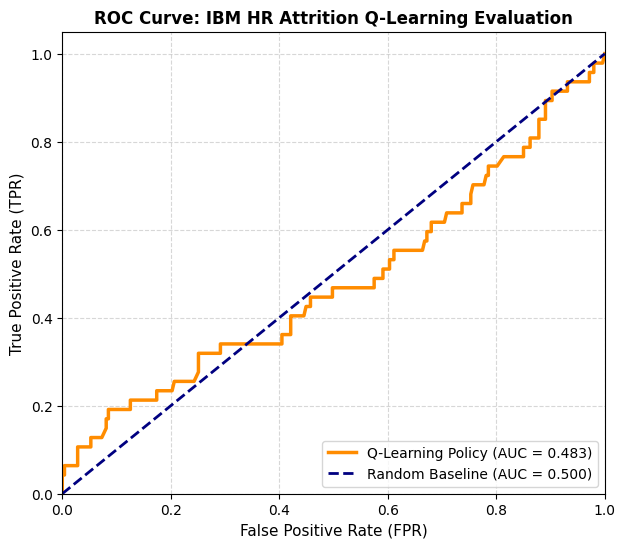

In [13]:
#Compute and Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, q_value_diffs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Q-Learning Policy (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Baseline (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('ROC Curve: IBM HR Attrition Q-Learning Evaluation', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("q_learning_ibm_hr_roc.png", dpi=300)
plt.show()

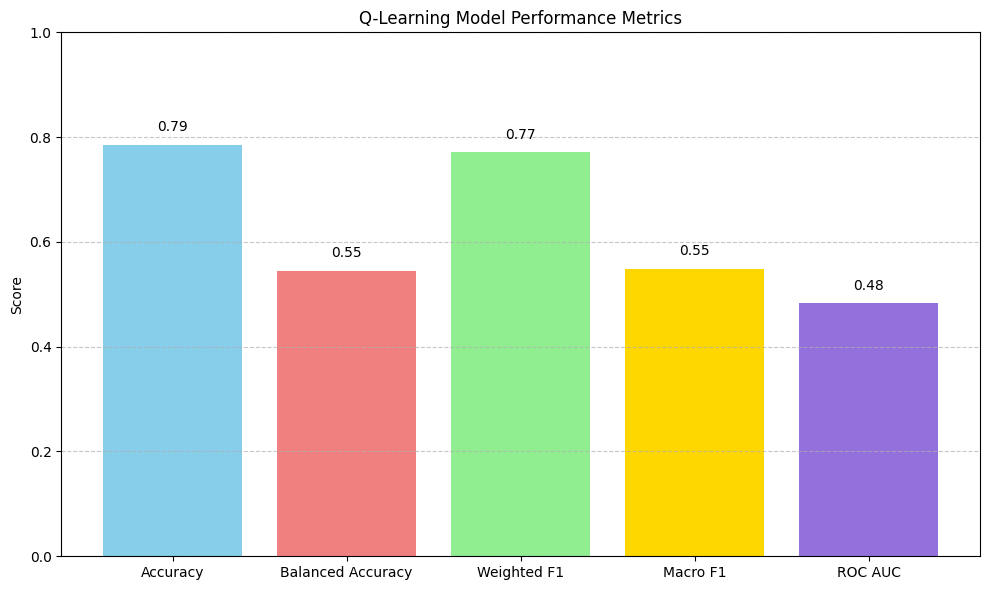

In [9]:
import matplotlib.pyplot as plt
import numpy as np

metrics_names = ['Accuracy', 'Balanced Accuracy', 'Weighted F1', 'Macro F1', 'ROC AUC']
metrics_values = [std_accuracy, bal_accuracy, weighted_f1, macro_f1, roc_auc]

plt.figure(figsize=(10, 6))
plt.bar(metrics_names, metrics_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple'])
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.ylabel('Score')
plt.title('Q-Learning Model Performance Metrics')

for i, value in enumerate(metrics_values):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("q_learning_performance_metrics_bar_chart.png")
plt.show()

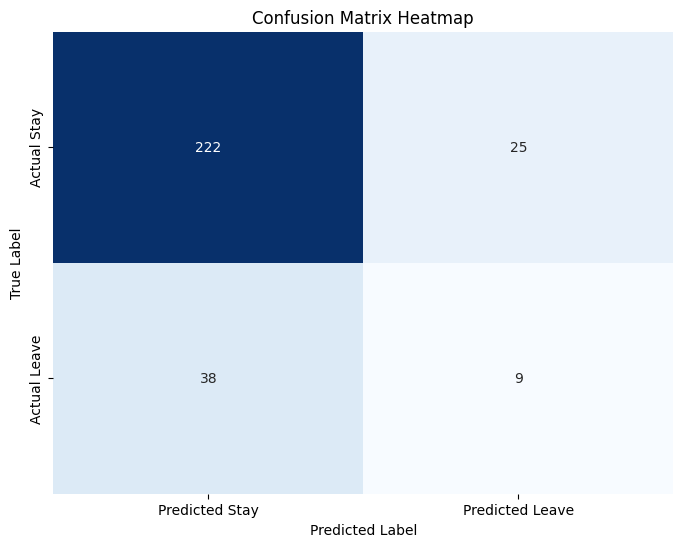

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, test_predictions)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Leave'],
            yticklabels=['Actual Stay', 'Actual Leave'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.savefig("q_learning_confusion_matrix_heatmap.png")
plt.show()

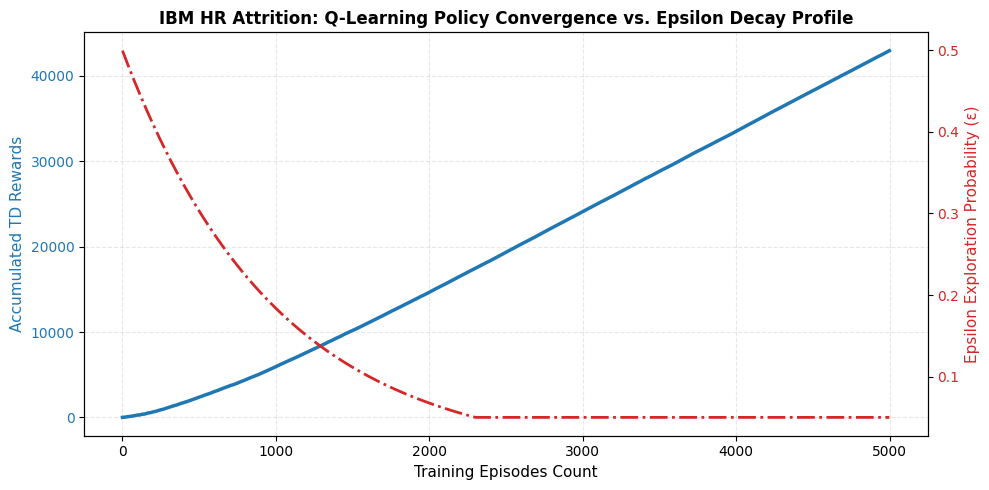

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot 1: Cumulative Reward (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Training Episodes Count', fontsize=11)
ax1.set_ylabel('Accumulated TD Rewards', color=color, fontsize=11)
ax1.plot(np.cumsum(reward_history), color=color, lw=2.5, label='Cumulative Reward')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)

# Plot 2: Epsilon Decay Policy (Right Axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Epsilon Exploration Probability (ε)', color=color, fontsize=11)
ax2.plot(epsilon_history, color=color, lw=2, linestyle='-.', label='Epsilon Decay Path')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('IBM HR Attrition: Q-Learning Policy Convergence vs. Epsilon Decay Profile', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig("ibm_hr_qlearning_convergence.png")
plt.show()

In [12]:
import pandas as pd

metrics_data = {
    'Metric': ['Standard Accuracy', 'Balanced Accuracy', 'Weighted F1 Score', 'Macro F1 Score', 'ROC AUC Score'],
    'Value': [std_accuracy, bal_accuracy, weighted_f1, macro_f1, roc_auc]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df['Value'] = metrics_df['Value'] * 100
csv_filename = 'IBM_HR_q_learning_performance_metrics.csv'
metrics_df.to_csv(csv_filename, index=False)

print(f"All Q-Learning performance metrics saved to {csv_filename}")
print(metrics_df)

All Q-Learning performance metrics saved to IBM_HR_q_learning_performance_metrics.csv
              Metric      Value
0  Standard Accuracy  78.571429
1  Balanced Accuracy  54.513739
2  Weighted F1 Score  77.126577
3     Macro F1 Score  54.898093
4      ROC AUC Score  48.281506
